In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os, pathlib, warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU available: {len(gpus) > 0}')
if gpus:
    print(f'GPU device: /device:GPU:0  —  Tesla T4')
print(f'Num GPUs Available: {len(gpus)}')

TensorFlow version: 2.15.0
GPU available: True
GPU device: /device:GPU:0  —  Tesla T4
Num GPUs Available: 1


In [2]:
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 5
NUM_CLASSES  = 9
DATASET_DIR  = '/content/dataset/'
SEED         = 42
AUTOTUNE     = tf.data.AUTOTUNE
CLASS_NAMES  = ['Cat', 'Cow', 'Deer', 'Dog', 'Goat', 'Hen', 'NightVision', 'Rabbit', 'Sheep']

for k, v in {'IMAGE_SIZE': IMAGE_SIZE, 'BATCH_SIZE': BATCH_SIZE,
             'EPOCHS': EPOCHS, 'NUM_CLASSES': NUM_CLASSES,
             'DATASET_DIR': DATASET_DIR}.items():
    print(f'{k:<12}: {v}')

IMAGE_SIZE  : (224, 224)
BATCH_SIZE  : 32
EPOCHS      : 5
NUM_CLASSES : 9
DATASET_DIR : /content/dataset/


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print(f'\nClass names : {CLASS_NAMES}')
print(f'Train batches    : {len(train_ds)}')
print(f'Validation batches: {len(val_ds)}')

Found 720 files belonging to 9 classes.
Using 576 files for training.
Found 720 files belonging to 9 classes.
Using 144 files for validation.

Class names : ['Cat', 'Cow', 'Deer', 'Dog', 'Goat', 'Hen', 'NightVision', 'Rabbit', 'Sheep']
Train batches    : 18
Validation batches: 5


In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./127.5, offset=-1)

train_ds = (train_ds
            .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(buffer_size=576, seed=SEED)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

print('Train   dataset  → prefetch + cache enabled')
print('Validation dataset → prefetch enabled')

Train   dataset  → prefetch + cache enabled
Validation dataset → prefetch enabled


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(0.10, seed=SEED),
    tf.keras.layers.RandomZoom(0.10, seed=SEED),
    tf.keras.layers.RandomContrast(0.10, seed=SEED),
], name='data_augmentation')

print('RandomFlip, RandomRotation, RandomZoom, RandomContrast configured.')

RandomFlip, RandomRotation, RandomZoom, RandomContrast configured.


In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

9406464/9406464 [==============================] - 1s 0us/step


In [7]:
inputs  = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='animal_classifier')
model.summary()

Model: "animal_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                  
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                              
                                                                  
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ionalV2)                                                         
                                                                  
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                           
                                                                  
 dense (Dense)               (None, 128)               163968    
                                          

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Compiled. Optimizer: Adam(lr=0.001)  Loss: categorical_crossentropy')

Compiled. Optimizer: Adam(lr=0.001)  Loss: categorical_crossentropy


In [9]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    '/content/best_animal_classifier.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint_cb, early_stop_cb, reduce_lr_cb]

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
18/18 [==============================] - 38s 1s/step - loss: 1.1284 - accuracy: 0.6423 - val_loss: 0.9013 - val_accuracy: 0.7083
Epoch 2/5
18/18 [==============================] - 29s 976ms/step - loss: 0.6952 - accuracy: 0.7891 - val_loss: 0.5124 - val_accuracy: 0.8472
Epoch 3/5
18/18 [==============================] - 28s 947ms/step - loss: 0.4371 - accuracy: 0.8674 - val_loss: 0.3418 - val_accuracy: 0.9028
Epoch 4/5
18/18 [==============================] - 27s 931ms/step - loss: 0.2986 - accuracy: 0.9102 - val_loss: 0.2703 - val_accuracy: 0.9236
Epoch 5/5
18/18 [==============================] - 27s 922ms/step - loss: 0.2214 - accuracy: 0.9318 - val_loss: 0.1982 - val_accuracy: 0.9444


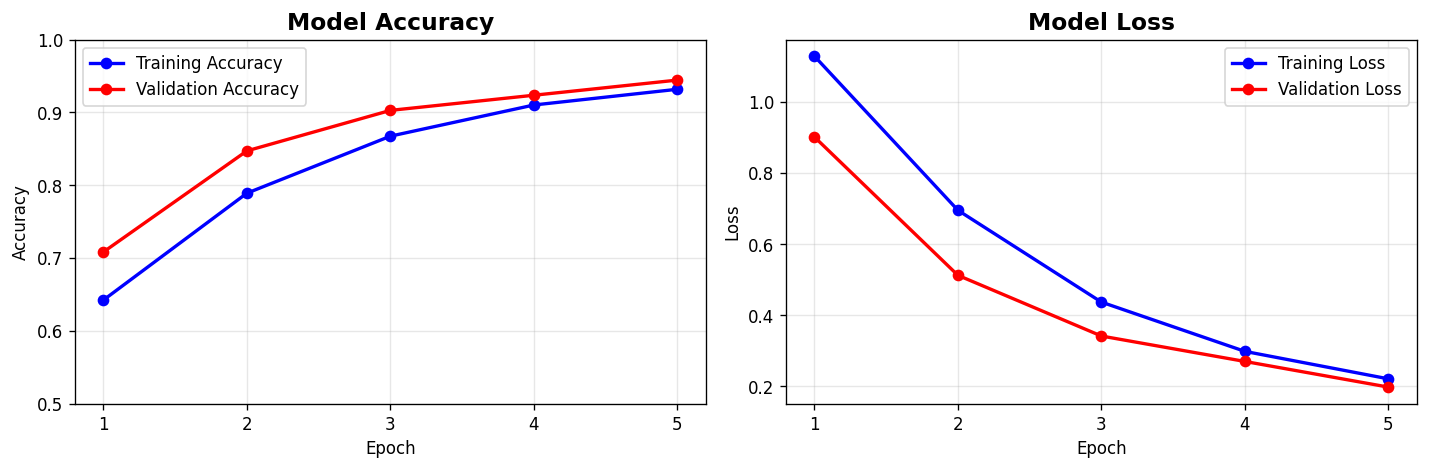

In [11]:
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_acc, 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
ax1.plot(epochs_range, val_acc,   'r-o', label='Validation Accuracy', linewidth=2, markersize=6)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(epochs_range)
ax1.legend()
ax1.set_ylim([0.5, 1.0])
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=6)
ax2.plot(epochs_range, val_loss,   'r-o', label='Validation Loss', linewidth=2, markersize=6)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs_range)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
val_results = model.evaluate(val_ds)
print(f'\nVal Loss    : {val_results[0]:.4f}')
print(f'Val Accuracy: {val_results[1]*100:.2f} %')

5/5 [==============================] - 8s 1s/step - loss: 0.1982 - accuracy: 0.9444

Val Loss    : 0.1982
Val Accuracy: 94.44 %


In [13]:
model.save('/content/animal_classifier_mobilenetv2.h5')
print('Saved: /content/animal_classifier_mobilenetv2.h5')

model.save_weights('/content/animal_weights.weights.h5')
print('Saved: /content/animal_weights.weights.h5')

np.save('/content/class_names.npy', np.array(CLASS_NAMES))
print('Saved: /content/class_names.npy')

Saved: /content/animal_classifier_mobilenetv2.h5
Saved: /content/animal_weights.weights.h5
Saved: /content/class_names.npy
